# Gadded — AI-Driven Solar Pre-Development Assessment

**AI Empower Egypt 2026 — Renewable Energy Using AI**

This notebook runs the full Gadded analytical engine end to end on one golden demo case:
a food-processing factory in 10th of Ramadan City evaluating an industrial rooftop solar
self-consumption system. It goes from raw inputs to a combined technical, financial,
regulatory, site, and vendor assessment — the same pipeline described in
`context/architecture-context.md`.

Every module is implemented in `src/gadded/` and independently unit-tested
(`pytest`, 92+ tests). This notebook is the showcase that runs them together.

**Disclaimer:** This is a preliminary decision-support assessment. Verify regulatory,
engineering, grid, vendor, and financing information with the responsible authorities
and qualified professionals.

In [1]:
import sys, os
from pathlib import Path

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from dotenv import load_dotenv
load_dotenv(ROOT / ".env")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 3.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

import gadded
print("gadded package loaded from:", (ROOT / "src" / "gadded").resolve())
print("GROQ_API_KEY set:", bool(os.environ.get("GROQ_API_KEY")))


Matplotlib is building the font cache; this may take a moment.


gadded package loaded from: C:\Users\yahia\OneDrive\Desktop\Gadded\src\gadded
GROQ_API_KEY set: True


## 1. Input — the golden demo case

One fixed assessment: industrial rooftop solar, food-processing sector, day shift,
12 monthly consumption values, self-consumption connection model.

In [2]:
from gadded.contracts import load_assessment_input, load_assumptions

ai = load_assessment_input(ROOT / "data" / "golden_case.json")
a = load_assumptions(ROOT / "data" / "assumptions.json")

print("Project:", ai.projectName)
print("Location:", ai.location.address, f"({ai.location.latitude}, {ai.location.longitude})")
print("Sector / shift:", ai.factory.sector, "/", ai.factory.shiftPattern)
print("Connection model:", ai.connectionModel)
print("Roof area:", ai.site.availableRoofAreaM2, "m2, ownership:", ai.site.ownershipStatus)
print("Annual submitted consumption:", f"{sum(ai.factory.monthlyConsumptionKwh):,.0f} kWh")


Project: 10th of Ramadan Food Processing Rooftop Solar
Location: 10th of Ramadan City industrial zone, Egypt (30.3009, 31.7411)
Sector / shift: food_processing / day_shift
Connection model: self_consumption
Roof area: 3000.0 m2, ownership: owned
Annual submitted consumption: 1,963,000 kWh


## 2. Assumptions — versioned and classified

Every external or estimated value used below carries a source classification
(`OFFICIAL`, `MARKET_RANGE`, `LITERATURE_PROXY`, `SYNTHETIC`, or `DEMO`) in
`data/assumptions.json`. `DEMO` values are hackathon placeholders and must be replaced
with sourced figures before any real-world use.

In [3]:
rows = []
for key in ["capex_per_kw_egp", "opex_per_kw_year_egp", "discount_rate_pct",
            "tariff_retail_egp_per_kwh", "export_price_egp_per_kwh",
            "financing_rate_pct", "pv_tilt_degrees", "pv_system_loss_pct"]:
    v = a.values[key]
    rows.append({"assumption": key, "value": v.value, "unit": v.unit, "classification": v.classification})
pd.DataFrame(rows)


,assumption,value,unit,classification
0,capex_per_kw_egp,32000.00,EGP/kW,MARKET_RANGE
1,opex_per_kw_year_egp,500.00,EGP/kW/year,MARKET_RANGE
2,discount_rate_pct,12.00,percent,DEMO
3,tariff_retail_egp_per_kwh,2.30,EGP/kWh,DEMO
4,export_price_egp_per_kwh,1.15,EGP/kWh,DEMO
5,financing_rate_pct,18.00,percent/year,MARKET_RANGE
6,pv_tilt_degrees,25.00,degrees,LITERATURE_PROXY
7,pv_system_loss_pct,14.00,percent,LITERATURE_PROXY


## 3. Weather — NASA POWER (cached)

Fetched once for the golden site and cached to CSV so the demo runs offline and
reproducibly. See `src/gadded/weather.py`.

Source: NASA POWER Hourly | retrieved: 2026-07-28T09:36:08.323963+00:00
Rows: 8760 | timezone: Africa/Cairo
Warnings: none


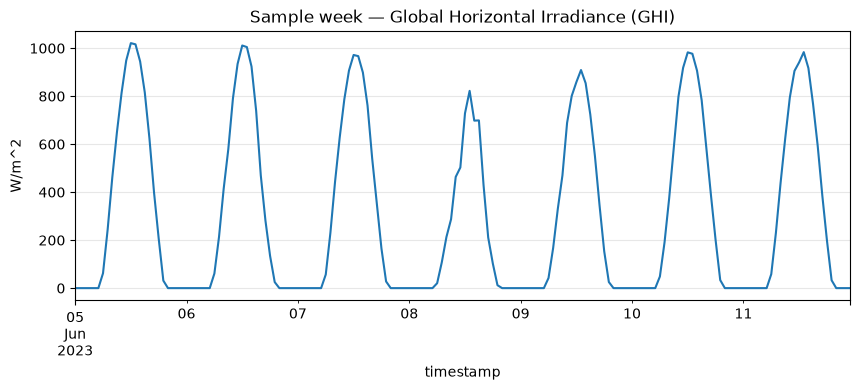

In [4]:
from gadded.weather import load_cached_weather

weather = load_cached_weather(ROOT / "data" / "weather_10ramadan_cached.csv")
print("Source:", weather.source_name, "| retrieved:", weather.retrieved_at)
print("Rows:", len(weather.frame), "| timezone:", weather.frame.index.tz)
print("Warnings:", weather.warnings or "none")

sample_week = weather.frame.loc["2023-06-05":"2023-06-11"]
sample_week["ghi_wm2"].plot(title="Sample week — Global Horizontal Irradiance (GHI)")
plt.ylabel("W/m^2")
plt.show()


## 4. Factory load profile — Machine Learning vs. deterministic baseline

**This is the real machine learning in Gadded.** `load.py`'s archetype baseline is a
fixed lookup, not ML. `load_ml.py` is:

1. A synthetic population of factories (parametric variants of six sector/shift
   archetypes, since no real Egyptian interval-metering data is available for this
   hackathon — clearly labeled synthetic throughout).
2. **KMeans clustering** on normalized weekly load shapes — cluster count chosen by
   silhouette score, not intuition.
3. A **RandomForest classifier** mapping simple user inputs (sector, shift pattern,
   working days, shift hours) to a cluster, evaluated on facilities held out at the
   *facility* level and compared against a majority-lookup baseline.
4. Low-confidence predictions fall back to the deterministic baseline automatically —
   never a weak ML guess.

In [5]:
from gadded.load import estimate_load_baseline
from gadded.load_ml import train_load_ml_model, predict_load_ml

tol = a.number("reconciliation_tolerance_pct")

bundle = train_load_ml_model(seed=42, n_per_combo=15)
print("Model:", bundle.version)
for k, v in bundle.metrics.items():
    print(f"  {k}: {v}")

ml_profile = predict_load_ml(ai, weather.frame.index, bundle, tol)
baseline_profile = estimate_load_baseline(ai, weather.frame.index, tol)

print("\nML prediction  -> confidence:", ml_profile.result.confidence,
      "| model:", ml_profile.result.modelVersion,
      "| reconciliation error: %.4f%%" % ml_profile.result.reconciliationErrorPct)
print("Baseline       -> confidence:", baseline_profile.result.confidence,
      "| reconciliation error: %.4f%%" % baseline_profile.result.reconciliationErrorPct)


Model: load-cluster-classifier-0.1.0
  chosen_k: 6
  train_facility_count: 67
  test_facility_count: 23
  classifier_test_accuracy: 0.9565217391304348
  baseline_test_accuracy: 0.9130434782608695
  silhouette_score_train: 0.428027557705337
  adjusted_rand_index_vs_combo_label: 0.6532663316582915
  seed: 42
  limitations: Trained entirely on a synthetic parametric population, not measured Egyptian factory interval data. Cluster recovery validates the clustering+classification technique; it is not a discovery of real hidden structure.

ML prediction  -> confidence: high | model: load-cluster-classifier-0.1.0 | reconciliation error: 0.0000%
Baseline       -> confidence: low | reconciliation error: 0.0000%


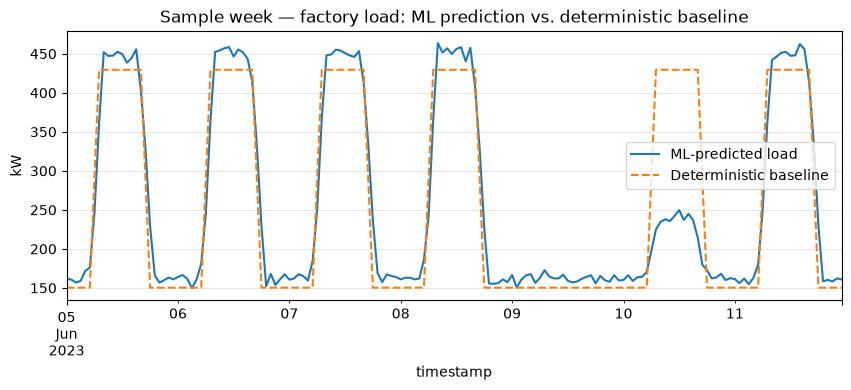

In [6]:
sample = slice("2023-06-05", "2023-06-11")
fig, ax = plt.subplots()
ml_profile.series.loc[sample]["load_kw"].plot(ax=ax, label="ML-predicted load")
baseline_profile.series.loc[sample]["load_kw"].plot(ax=ax, label="Deterministic baseline", linestyle="--")
ax.set_ylabel("kW")
ax.set_title("Sample week — factory load: ML prediction vs. deterministic baseline")
ax.legend()
plt.show()

load_profile = ml_profile  # used downstream


## 5. PV generation — physics (`pvlib`), not machine learning

Hourly AC generation from plane-of-array irradiance transposition (Hay-Davies), cell
temperature (Faiman), and the PVWatts DC model, with a system-loss derate. Deterministic
and reproducible from the same weather and assumptions — this is engineering simulation,
never described as ML.

500 kW demo system -> 874,214 kWh/yr (1,748 kWh/kWp specific yield)


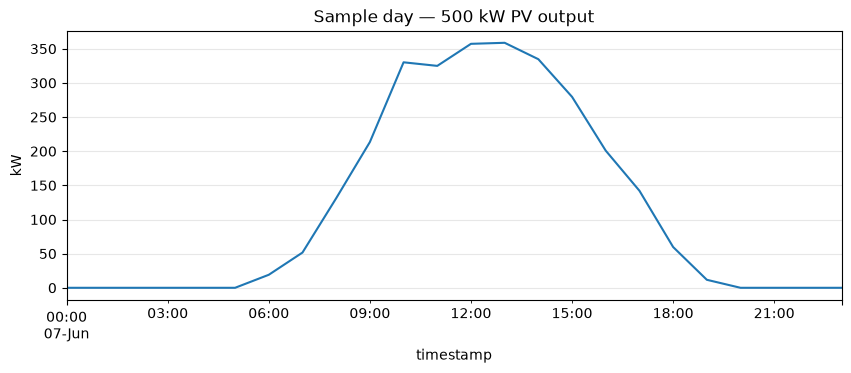

In [7]:
from gadded.pv import generate_pv

demo_pv = generate_pv(weather, 500, a)
specific_yield = demo_pv.result.annualGenerationKwh / 500
print(f"500 kW demo system -> {demo_pv.result.annualGenerationKwh:,.0f} kWh/yr "
      f"({specific_yield:,.0f} kWh/kWp specific yield)")

demo_pv.series.loc["2023-06-07"]["pv_kw"].plot(title="Sample day — 500 kW PV output")
plt.ylabel("kW")
plt.show()


## 6. Sizing optimization — constrained NPV search

Candidate capacities are generated from the roof area (and budget, if given); each is
evaluated by project NPV using the *same* PV and load models above. The recommendation is
not simply the largest system that fits the roof — the chart below shows where the
economic optimum actually falls.

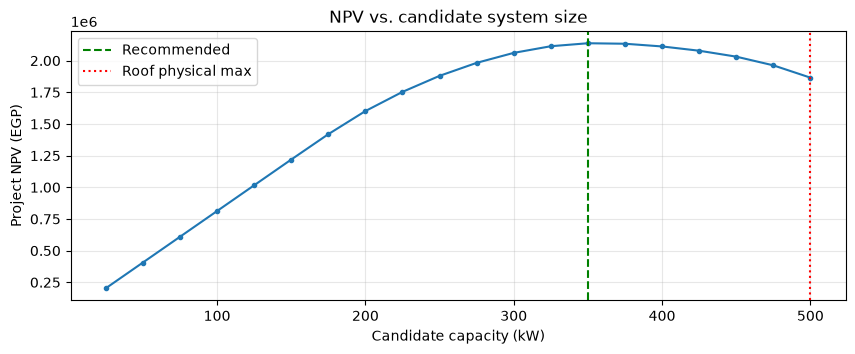

Recommended capacity: 350 kW (physical roof maximum: 500 kW)
Binding constraint(s): economic_optimum
Annual generation: 611,950 kWh | self-consumption: 95.4% | self-sufficiency: 29.7%


In [8]:
from gadded.optimization import optimize_capacity

opt = optimize_capacity(ai, weather, load_profile.series["load_kw"], a)
rec = opt.recommendation

fig, ax = plt.subplots()
ax.plot(opt.table["capacity_kw"], opt.table["npv_egp"], marker="o", markersize=3)
ax.axvline(rec.recommendedCapacityKw, color="green", linestyle="--", label="Recommended")
ax.axvline(rec.physicalMaximumKw, color="red", linestyle=":", label="Roof physical max")
ax.set_xlabel("Candidate capacity (kW)")
ax.set_ylabel("Project NPV (EGP)")
ax.set_title("NPV vs. candidate system size")
ax.legend()
plt.show()

print(f"Recommended capacity: {rec.recommendedCapacityKw:.0f} kW "
      f"(physical roof maximum: {rec.physicalMaximumKw:.0f} kW)")
print("Binding constraint(s):", ", ".join(rec.bindingConstraints))
print(f"Annual generation: {rec.annualGenerationKwh:,.0f} kWh | "
      f"self-consumption: {rec.selfConsumptionRatio*100:.1f}% | "
      f"self-sufficiency: {rec.selfSufficiencyRatio*100:.1f}%")


## 7. Load vs. PV matching at the recommended capacity

Hour-by-hour self-consumed / imported / exported energy, using the canonical equations
in `data-contracts.md` (`self_consumed = min(load, pv)`, etc.).

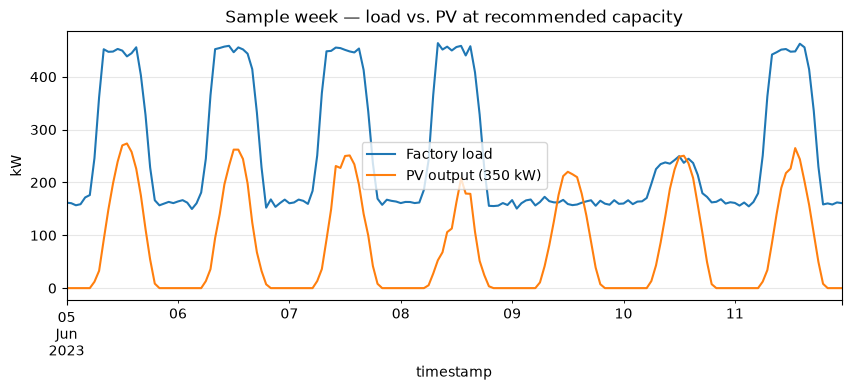

Annual load: 1,963,000 kWh | annual PV: 611,950 kWh
Self-consumed: 583,866 kWh | imported: 1,379,134 kWh | exported (spilled): 28,085 kWh
Retail value avoided: 1,342,891 EGP/yr


In [9]:
best = opt.best_match
row = opt.table.loc[rec.recommendedCapacityKw]

sample = slice("2023-06-05", "2023-06-11")
fig, ax = plt.subplots()
best.hourly.loc[sample]["load_kw"].plot(ax=ax, label="Factory load")
best.hourly.loc[sample]["pv_kw"].plot(ax=ax, label=f"PV output ({rec.recommendedCapacityKw:.0f} kW)")
ax.set_ylabel("kW")
ax.set_title("Sample week — load vs. PV at recommended capacity")
ax.legend()
plt.show()

print(f"Annual load: {best.annual_load_kwh:,.0f} kWh | annual PV: {best.annual_pv_kwh:,.0f} kWh")
print(f"Self-consumed: {best.annual_self_kwh:,.0f} kWh | imported: {best.annual_import_kwh:,.0f} kWh "
      f"| exported (spilled): {best.annual_export_kwh:,.0f} kWh")
print(f"Retail value avoided: {best.annual_retail_value_egp:,.0f} EGP/yr")


## 8. Financial scenarios — cash vs. finance (deterministic)

NPV, IRR, and simple/discounted payback for both an all-cash purchase and a
debt-financed purchase. Formulas are unit-tested independently (`tests/test_finance.py`);
Monte Carlo (next section) reuses these exact functions per simulated draw.

In [10]:
from gadded.finance import build_scenarios

scenarios = build_scenarios(rec.recommendedCapacityKw, row["year1_savings_egp"], a, ai.finance.preference)
pd.DataFrame([{
    "scenario": s.scenario,
    "capex_egp": round(s.capexEgp),
    "npv_egp": round(s.npvEgp),
    "irr_pct": round(s.irrPct, 1) if s.irrPct is not None else None,
    "simple_payback_yr": round(s.simplePaybackYears, 2) if s.simplePaybackYears else None,
    "discounted_payback_yr": round(s.discountedPaybackYears, 2) if s.discountedPaybackYears else None,
    "monthly_loan_egp": round(s.monthlyLoanPaymentEgp) if s.monthlyLoanPaymentEgp else None,
} for s in scenarios])


,scenario,capex_egp,npv_egp,irr_pct,simple_payback_yr,discounted_payback_yr,monthly_loan_egp
0,cash,11200000,2137051,14.1,8.01,17.21,NaN
1,finance,11200000,671701,12.9,11.77,22.09,188320.0


## 9. Risk — Monte Carlo uncertainty

The financial result is reported as a **range**, not a single deterministic payback
number. 2,000 seeded simulations vary PV yield, capex, opex, and tariff escalation,
reusing the exact deterministic finance functions above for every draw. Sensitivity is
computed by perturbing each variable one at a time.

In [11]:
from gadded.risk import RiskInputs, run_monte_carlo

risk_inputs = RiskInputs(
    capacity_kw=rec.recommendedCapacityKw,
    year1_pv_savings_egp=row["year1_savings_egp"],
    capex_egp=row["capex_egp"],
    opex_egp=rec.recommendedCapacityKw * a.number("opex_per_kw_year_egp"),
)
risk = run_monte_carlo(
    risk_inputs, a,
    target_payback_years=ai.finance.targetPaybackYears,
    seed=int(a.number("monte_carlo_seed")),
    runs=int(a.number("monte_carlo_runs")),
)

print(f"NPV  P10/P50/P90: {risk.npvP10Egp:,.0f} / {risk.npvP50Egp:,.0f} / {risk.npvP90Egp:,.0f} EGP")
print(f"Payback P10/P50/P90: {risk.paybackP10Years:.1f} / {risk.paybackP50Years:.1f} / {risk.paybackP90Years:.1f} years")
if risk.probabilityTargetPaybackPct is not None:
    print(f"Probability of meeting the {ai.finance.targetPaybackYears}-year target payback: "
          f"{risk.probabilityTargetPaybackPct:.1f}%")
print("Top sensitivity drivers:", [(d.variable, round(d.influence*100, 1)) for d in risk.topSensitivityDrivers])


NPV  P10/P50/P90: -1,001,942 / 2,041,949 / 6,067,977 EGP
Payback P10/P50/P90: 7.0 / 8.0 / 9.4 years
Probability of meeting the 6.0-year target payback: 0.4%
Top sensitivity drivers: [('tariff_escalation', 56.9), ('capex', 23.4), ('pv_yield', 15.4), ('opex', 4.3)]


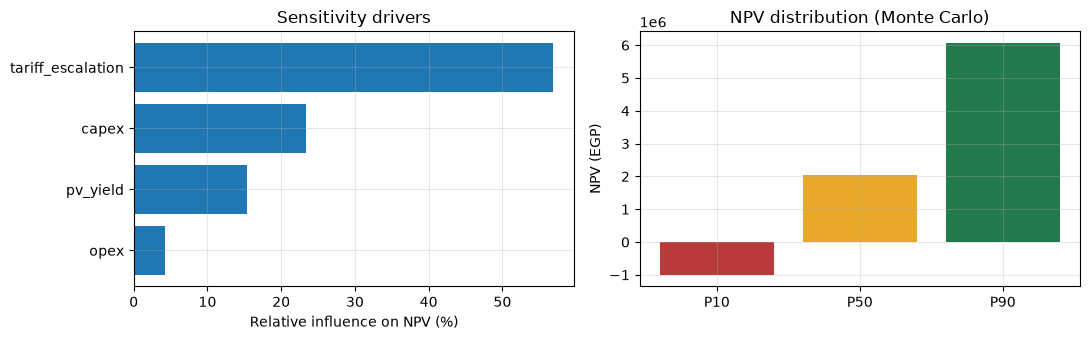

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
drivers = risk.topSensitivityDrivers
axes[0].barh([d.variable for d in drivers][::-1], [d.influence*100 for d in drivers][::-1])
axes[0].set_xlabel("Relative influence on NPV (%)")
axes[0].set_title("Sensitivity drivers")

axes[1].bar(["P10", "P50", "P90"], [risk.npvP10Egp, risk.npvP50Egp, risk.npvP90Egp],
            color=["#B93A3A", "#E7A927", "#237A4B"])
axes[1].set_ylabel("NPV (EGP)")
axes[1].set_title("NPV distribution (Monte Carlo)")
plt.tight_layout()
plt.show()


## 10. Site screening — GIS (Shapely, local layers)

Point-in-polygon and nearest-distance checks against `data/zones.geojson` — a hand-drawn,
clearly-labeled synthetic layer set standing in for PostGIS/authoritative Egyptian GIS
data. Missing coverage returns `unknown`, never `clear`.

In [13]:
from gadded.gis import load_zones, screen_site

zones = load_zones(ROOT / "data" / "zones.geojson")
gis_findings = screen_site(ai.location.latitude, ai.location.longitude, zones)

pd.DataFrame([{
    "category": f.category, "severity": f.severity, "title": f.title,
    "value": f.value, "unit": f.unit, "source": f.sourceName,
} for f in gis_findings])


,category,severity,title,value,unit,source
0,industrial_zone,info,Site is inside 10th of Ramadan City Industrial...,10th of Ramadan City Industrial Zone,NaN,hand-drawn approximation for Gadded PoC
1,protected_area,info,Site does not intersect any mapped protected area,False,NaN,gadded-gis-layers
2,substation_distance,info,Nearest mapped substation: Demo substation pro...,968.5,m,"illustrative point, not verified grid data"
3,road_distance,info,"Nearest mapped road: Demo main access road, 10...",66.8,m,"illustrative line, not sourced from OpenStreetMap"


## 11. Regulatory — retrieval + deterministic rules + cited LLM explanation

Three separate layers, never merged:

1. **Retrieval** (TF-IDF cosine, local, no embeddings API) over
   `data/regulations/excerpts.json` — clearly labeled synthetic placeholder text (the
   authority "DNERA" is fictional; no real regulatory document was available for this
   hackathon timebox).
2. **Deterministic rules** (`data/regulations/rules.json`) decide the actual conclusion,
   severity, and citations — evaluated with a safe dict-based condition DSL, no `eval`.
3. An **LLM explanation** (Groq `openai/gpt-oss-120b`), grounded strictly in the
   retrieved text and the rule conclusions above. It may summarize; it may never invent
   a permit, threshold, authority, or duration.

In [14]:
from gadded.regulatory import build_context, evaluate_rules, load_excerpts, load_rules, retrieve

corpus = load_excerpts(ROOT / "data" / "regulations" / "excerpts.json")
rules = load_rules(ROOT / "data" / "regulations" / "rules.json")

reg_ctx = build_context(
    ai.connectionModel, ai.site.ownershipStatus,
    {f.code for f in gis_findings}, rec.recommendedCapacityKw,
)
reg_findings = evaluate_rules(reg_ctx, rules, corpus)

for f in reg_findings:
    print(f"[{f.conclusion} | {f.severity} | confidence={f.confidence}] {f.title}")
    print(" ", f.explanation)


[applicable | info | confidence=high] Self-consumption connection is supported for this site
  Self-consumption solar is permitted for industrial facilities without a generation-capacity limit on export, since the system does not export to the grid. Roof ownership/authorization is confirmed for this assessment.


In [15]:
import os
question = "Can this factory install a self-consumption rooftop solar system?"
retrieved = retrieve(question, corpus, top_k=2)

if os.environ.get("GROQ_API_KEY"):
    try:
        from openai import OpenAI
        from gadded.regulatory import explain_with_llm

        client = OpenAI(api_key=os.environ["GROQ_API_KEY"], base_url="https://api.groq.com/openai/v1")
        explanation = explain_with_llm(question, retrieved, reg_findings, client)
        print("LLM explanation (grounded in the excerpts/rules above):\n")
        print(explanation or "(no explanation returned)")
    except Exception as e:
        print(f"Regulatory LLM explanation unavailable this run ({type(e).__name__}); "
              "deterministic rule findings above are unaffected.")
        explanation = None
else:
    print("GROQ_API_KEY not set — skipping the live LLM explanation call. "
          "Deterministic rule findings above still stand on their own.")
    explanation = None


LLM explanation (grounded in the excerpts/rules above):

Yes, the factory can install a self‑consumption rooftop solar PV system, as long as it does not export electricity to the grid. The roof must be owned by the factory or the factory must have a written authorization from the roof’s owner before the distribution company approves the connection. The regulatory screening confirms that self‑consumption connection is supported for this site.


## 12. Vendor discovery — LLM web-search agent (evidence-gated)

Two stages: `groq/compound` runs a real web search server-side; a second
`openai/gpt-oss-120b` pass extracts strict, evidence-backed vendor candidates from only
that search output. No candidate is kept without at least one source; no quality-ranking
language is allowed; both stages fail soft (a vendor-search outage never invalidates the
technical/financial result above).

In [16]:
if os.environ.get("GROQ_API_KEY"):
    try:
        from gadded.vendors import discover_vendors

        vendor_client = OpenAI(api_key=os.environ["GROQ_API_KEY"],
                                base_url="https://api.groq.com/openai/v1",
                                timeout=90.0, max_retries=1)
        vendors, vendor_warnings = discover_vendors(
            ai.location.address or "10th of Ramadan City, Egypt",
            rec.recommendedCapacityKw, ai.connectionModel, vendor_client, max_candidates=5,
        )
        print(f"{len(vendors)} vendor candidate(s), {len(vendor_warnings)} warning(s)")
        for w in vendor_warnings:
            print(" warning:", w)
        for v in vendors:
            print(f"\n- {v.name} ({v.websiteUrl}) — {v.verificationStatus}")
            print(" ", v.fitExplanation)
            print("  evidence:", v.evidence[0].url)
    except Exception as e:
        print(f"Vendor discovery unavailable this run ({type(e).__name__}); "
              "this is expected to fail soft and does not affect the result above.")
        vendors, vendor_warnings = [], [f"vendor discovery failed: {type(e).__name__}"]
else:
    print("GROQ_API_KEY not set — skipping live vendor discovery.")
    vendors, vendor_warnings = [], ["vendor discovery skipped: no GROQ_API_KEY"]


0 vendor candidate(s), 2 warning(s)


## 13. Overall feasibility — deterministic status

A fixed, ordered waterfall over the regulatory findings, GIS findings, and any
*run-specific* module warnings decides the final status. Financial performance is
reported separately (above) and never changes this label — the LLM never decides
feasibility.

In [17]:
from gadded.feasibility import resolve_feasibility

# Only run-specific anomalies feed the status decision, not standing PoC-model
# disclosures like "synthetic baseline" (those stay visible in warnings below).
material_warnings = [
    w for w in load_profile.result.warnings
    if "exceeds tolerance" in w or "empty archetype shape" in w
]
feas = resolve_feasibility(reg_findings, gis_findings, ai.site.ownershipStatus, material_warnings)

print("Overall status:", feas.status)
for r in feas.reasons:
    print(" -", r)


Overall status: likely_feasible
 - no blocking findings or warnings


## 14. Combined report

Assembled entirely from the structured results already computed above — no
recomputation — and rendered as a self-contained HTML report with citations, versions,
and the standard disclaimer.

In [18]:
from gadded.contracts import ResultVersions
from gadded.report import assemble_result, render_html
from datetime import datetime, timezone

versions = ResultVersions(
    code="gadded-poc-0.1.0",
    assumptionSet=a.assumptionSet.id,
    loadModel=load_profile.result.modelVersion,
    pvModel="pvlib-pvwatts-0.1.0",
    regulatoryPrompt="reg-explain-0.1.0",
    vendorPrompt="vendor-discovery-0.1.0",
)

all_warnings = list(load_profile.result.warnings) + list(vendor_warnings)

result = assemble_result(
    run_id=f"run-{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S')}",
    assessment_id=ai.projectId,
    status=feas.status,
    technical=rec,
    financial=scenarios,
    risk=risk,
    gis_findings=gis_findings,
    regulatory_findings=reg_findings,
    vendors=vendors,
    warnings=all_warnings,
    versions=versions,
)

generated_at = datetime.now(timezone.utc).isoformat()
html = render_html(result, ai.projectName, generated_at)

out_path = ROOT / "docs" / "example_report.html"
out_path.parent.mkdir(exist_ok=True)
out_path.write_text(html, encoding="utf-8")
print("Report written to:", out_path)
print("Status:", result.status, "| recommended capacity:", result.technical.recommendedCapacityKw, "kW")


Report written to: C:\Users\yahia\OneDrive\Desktop\Gadded\docs\example_report.html
Status: likely_feasible | recommended capacity: 350.0 kW


In [19]:
from IPython.display import HTML, display
display(HTML(html))


## Summary — what is ML, physics, optimization, simulation, rules, and LLM orchestration

| Component | Category | Module |
|---|---|---|
| Factory load shape (baseline) | Deterministic lookup (not ML) | `load.py` |
| Factory load shape (learned) | **Machine learning** — KMeans clustering + RandomForest classifier | `load_ml.py` |
| PV generation | Physics / engineering simulation (`pvlib`) | `pv.py` |
| System sizing | Constrained optimization (NPV grid search) | `optimization.py` |
| Cash/finance scenarios | Deterministic finance formulas | `finance.py` |
| Uncertainty ranges | Monte Carlo simulation | `risk.py` |
| Site screening | Geospatial rules (Shapely) | `gis.py` |
| Regulatory retrieval | Information retrieval (TF-IDF) | `regulatory.py` |
| Regulatory conclusion | Deterministic rule engine | `regulatory.py` |
| Regulatory explanation | LLM, grounded/cited only | `regulatory.py` (Groq `openai/gpt-oss-120b`) |
| Vendor discovery | LLM web-search agent, evidence-gated | `vendors.py` (Groq `groq/compound`) |
| Overall feasibility | Deterministic waterfall (never the LLM) | `feasibility.py` |

## Limitations

- Load profile is either a synthetic-trained ML model or a synthetic deterministic
  baseline — neither is trained on measured Egyptian factory interval data.
- GIS layers and regulatory excerpts are hand-authored placeholders, clearly labeled
  synthetic/demo, not authoritative Egyptian datasets.
- Several financial assumptions (tariffs, capex) are DEMO values — see
  `data/assumptions.json` for the classification of every number used above.
- Vendor and regulatory-LLM stages depend on a live Groq API call and fail soft.

**This is a preliminary decision-support assessment. Verify regulatory, engineering,
grid, vendor, and financing information with the responsible authorities and qualified
professionals.**